In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_ = pd.read_csv("C:/Users/Casper/Desktop/Proje/airbnbistdb.csv")
df=df_.copy()

In [4]:
df.head()

,id,source,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,607344,city scrape,2751565,Volkan,2012-06-26,"İstanbul, Turkey",within an hour,100%,100%,t,...,498.0,50.0,50.0,482.0,t,3,3,0,0,44
1,34177,city scrape,147330,Ercan,2010-06-18,"Istanbul, Turkey",within an hour,100%,55%,t,...,488.0,481.0,469.0,481.0,f,2,2,0,0,15
2,612327,city scrape,2911496,Nadira,2012-07-12,"Paris, France",within a few hours,100%,89%,t,...,491.0,488.0,49.0,473.0,f,1,1,0,0,208
3,618156,city scrape,2999837,Saban,2012-07-20,NaN,within an hour,99%,100%,f,...,451.0,469.0,44.0,441.0,t,10,10,0,0,74
4,630800,city scrape,485384,Alev,2011-04-05,"Istanbul, Turkey",within an hour,100%,100%,t,...,474.0,489.0,477.0,458.0,f,2,2,0,0,68


In [5]:
df.shape

(19402, 57)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19402 entries, 0 to 19401
Data columns (total 57 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            19402 non-null  int64  
 1   source                                        19402 non-null  object 
 2   host_id                                       19402 non-null  int64  
 3   host_name                                     19402 non-null  object 
 4   host_since                                    19402 non-null  object 
 5   host_location                                 14215 non-null  object 
 6   host_response_time                            18044 non-null  object 
 7   host_response_rate                            18044 non-null  object 
 8   host_acceptance_rate                          18507 non-null  object 
 9   host_is_superhost                             18924 non-null 

In [7]:
df["host_id"] = df["host_id"].astype("object")
df["id"] = df["id"].astype("object")

In [8]:
df[["id","host_id"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19402 entries, 0 to 19401
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       19402 non-null  object
 1   host_id  19402 non-null  object
dtypes: object(2)
memory usage: 303.3+ KB


In [9]:
## "bathrooms","bedrooms" ve "beds" değerleri mantıksız olduğu için düzenlemesi aşağıdaki gibidir. 
df["bathrooms"]=df["bathrooms"]/10
df["bedrooms"]=df["bedrooms"]/10
df["beds"]=df["beds"]/10

In [10]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

In [11]:
df["host_since"] = pd.to_datetime(df["host_since"])

In [12]:
## Price satırı sembollerden dolayı object görünüyor bu nedenle sembollerden kurtulmamız gerektiği için temizledik. 
df['price_clean'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

In [13]:
df["price"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 19402 entries, 0 to 19401
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
18084 non-null  object
dtypes: object(1)
memory usage: 151.7+ KB


In [14]:
df["price"].isnull().sum()

np.int64(1318)

In [15]:
df["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Beyoglu          5862
Sisli            2584
Fatih            2545
Kadikoy          1782
Besiktas         1181
Esenyurt          493
Kagithane         462
Uskudar           459
Bagcilar          369
Atasehir          340
Bahcelievler      283
Maltepe           248
Sile              239
Adalar            229
Bakirkoy          212
Avcilar           184
Sariyer           177
Umraniye          171
Pendik            162
Basaksehir        153
Kucukcekmece      148
Eyup              144
Arnavutkoy        131
Zeytinburnu       127
Kartal            125
Beylikduzu        113
Beykoz             88
Buyukcekmece       79
Tuzla              62
Gaziosmanpasa      50
Silivri            43
Gungoren           43
Esenler            26
Cekmekoy           25
Catalca            20
Bayrampasa         17
Sultangazi         11
Sultanbeyli         8
Sancaktepe          7
Name: count, dtype: int64

In [16]:
df["room_type"].value_counts()

room_type
Entire home/apt    14730
Private room        4380
Hotel room           174
Shared room          118
Name: count, dtype: int64

In [17]:
df["accommodates"].max()
print("maksimum konaklayabilecek kişi sayısı:", df["accommodates"].max())
df["accommodates"].min()
print("maksimum konaklayabilecek kişi sayısı:", df["accommodates"].min())

maksimum konaklayabilecek kişi sayısı: 16
maksimum konaklayabilecek kişi sayısı: 1


In [18]:
corr_matrix = df.corr(numeric_only=True)

In [19]:
corr_matrix

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean
host_listings_count,1.000000,0.929251,0.020783,0.029958,-0.023302,0.014652,-0.006128,-0.027279,0.036342,-0.019671,...,-0.029334,-0.019275,-0.031327,-0.032452,0.962647,0.958612,0.053916,-0.003594,-0.030562,0.000526
host_total_listings_count,0.929251,1.000000,0.024696,0.024414,-0.004404,0.030141,0.007471,-0.010337,0.024903,-0.010891,...,-0.023135,-0.013524,-0.025373,-0.025889,0.829234,0.827349,0.034084,-0.005867,-0.021901,0.001529
latitude,0.020783,0.024696,1.000000,0.335555,0.000780,-0.009983,0.003964,-0.029072,-0.005050,-0.058281,...,-0.048674,-0.068034,-0.035045,-0.046326,0.017342,0.020727,-0.026568,-0.013463,0.036453,-0.006362
longitude,0.029958,0.024414,0.335555,1.000000,0.011432,-0.002586,0.010186,-0.040094,0.000971,-0.082760,...,-0.074049,-0.087690,-0.064351,-0.063358,0.028880,0.033189,-0.029088,-0.021600,0.049846,-0.008288
accommodates,-0.023302,-0.004404,0.000780,0.011432,1.000000,0.394969,0.523041,0.601463,0.018431,0.035855,...,0.030573,0.014220,0.037766,0.027891,-0.033118,-0.017223,-0.190459,-0.016342,0.035529,0.063669
bathrooms,0.014652,0.030141,-0.009983,-0.002586,0.394969,1.000000,0.639755,0.487646,0.015103,0.007545,...,-0.030462,-0.024277,-0.025954,-0.022974,0.003548,0.004400,-0.003725,0.038733,-0.034766,0.041373
bedrooms,-0.006128,0.007471,0.003964,0.010186,0.523041,0.639755,1.000000,0.613802,0.006597,0.001256,...,-0.022592,-0.025535,-0.023314,-0.024543,-0.014595,-0.008408,-0.065485,-0.018872,-0.022692,0.053197
beds,-0.027279,-0.010337,-0.029072,-0.040094,0.601463,0.487646,0.613802,1.000000,0.010746,0.064495,...,0.029239,0.025140,0.031296,0.029659,-0.033337,-0.029213,-0.065629,0.118888,-0.042138,0.046327
minimum_nights,0.036342,0.024903,-0.005050,0.000971,0.018431,0.015103,0.006597,0.010746,1.000000,0.019983,...,-0.020703,-0.021310,-0.008057,-0.010438,0.031380,0.033736,-0.035264,0.069447,-0.057400,0.001831
maximum_nights,-0.019671,-0.010891,-0.058281,-0.082760,0.035855,0.007545,0.001256,0.064495,0.019983,1.000000,...,0.101881,0.099574,0.098854,0.102317,-0.018316,-0.015434,-0.019486,-0.004668,-0.004907,0.013863


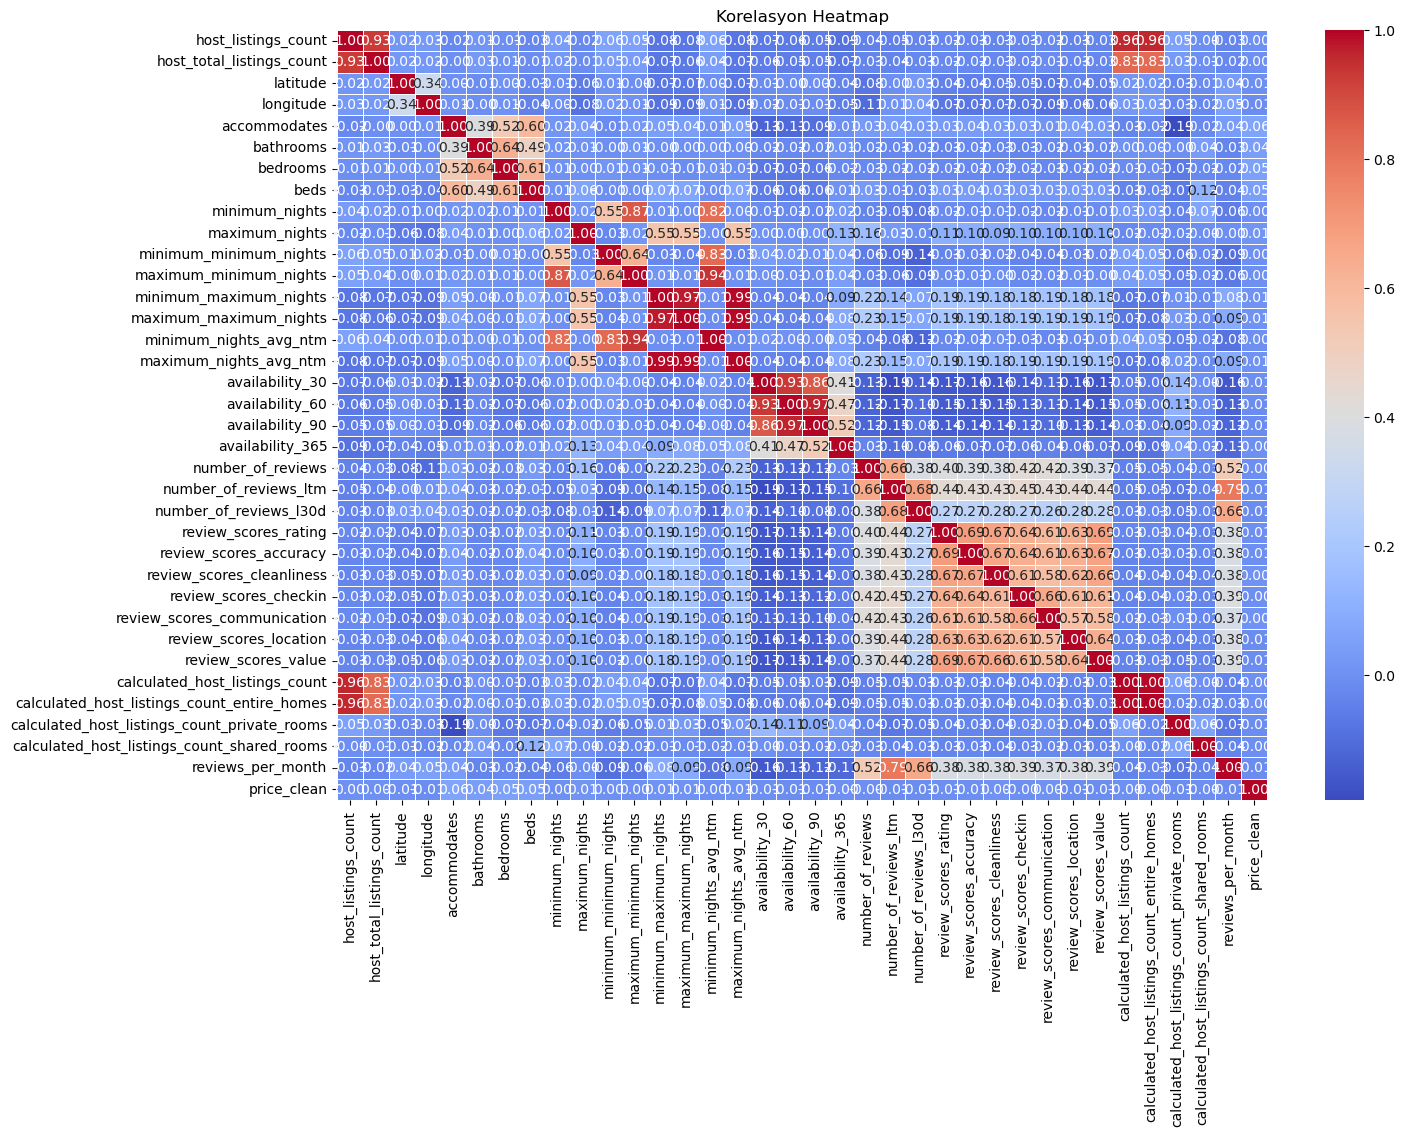

In [20]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    corr_matrix,
    annot=True,      # Korelasyon değerlerini yazar
    cmap="coolwarm", # Renk paleti
    fmt=".2f",       # Virgülden sonra 2 basamak
    linewidths=0.5
)

plt.title("Korelasyon Heatmap")
plt.show()

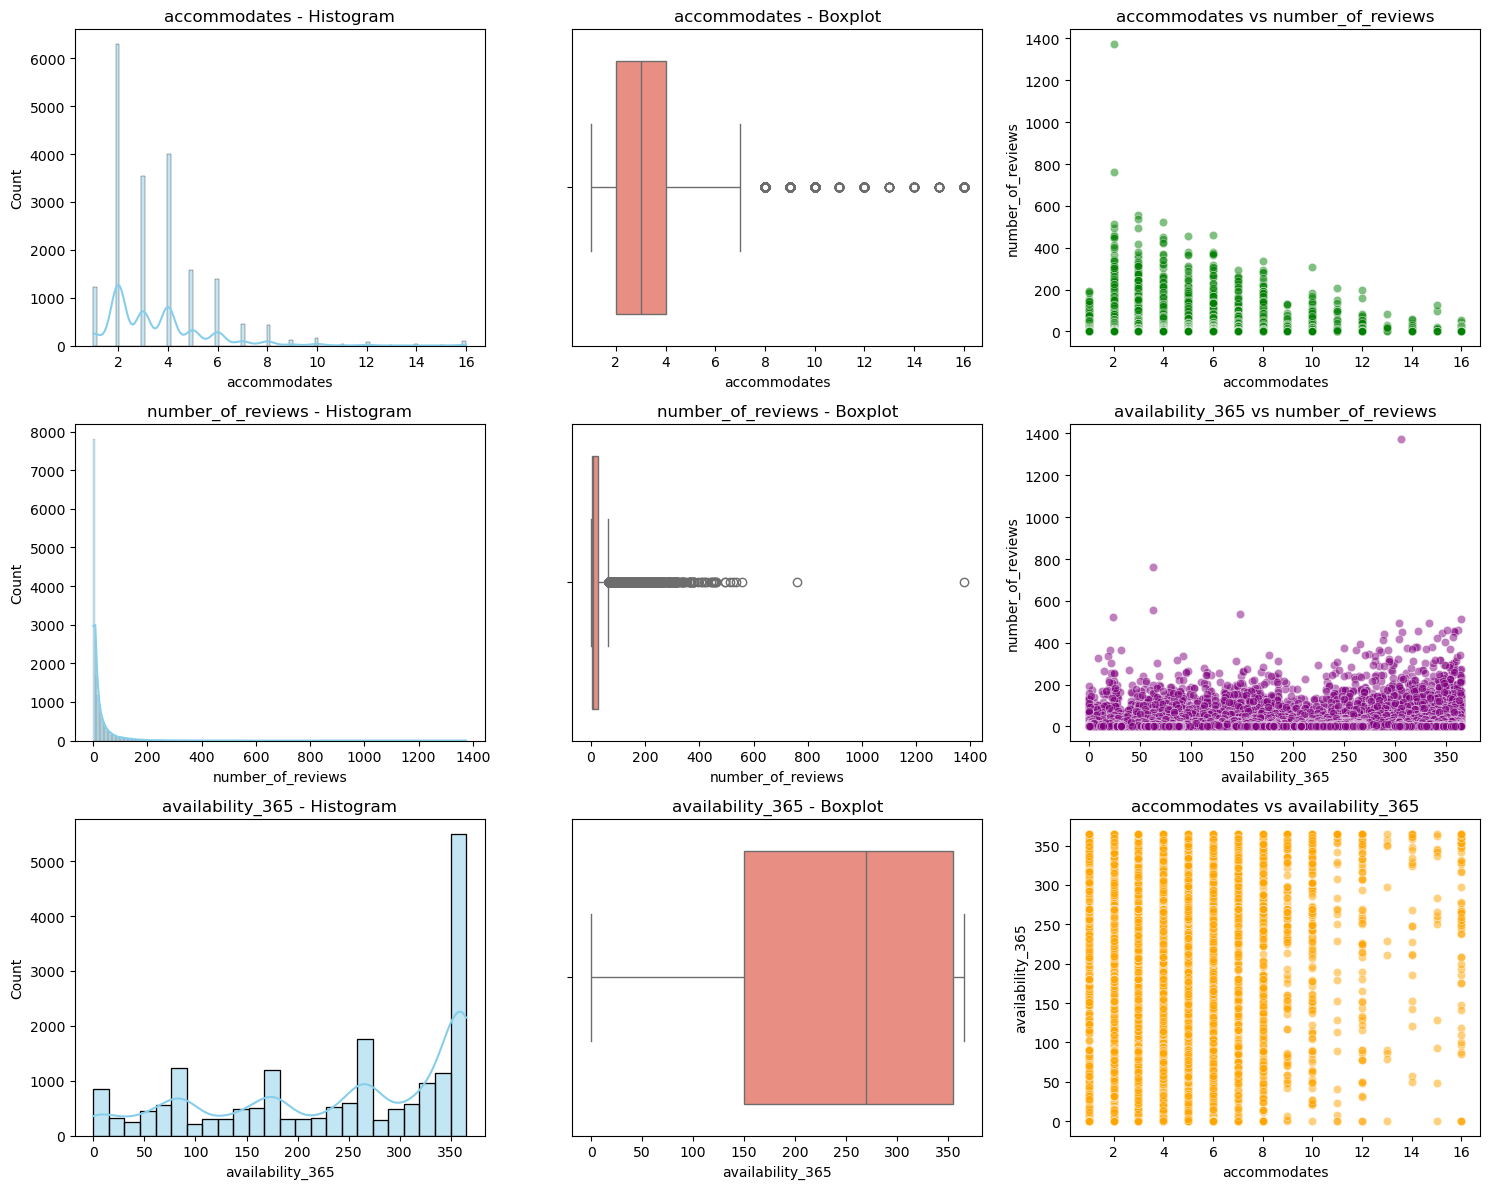

In [21]:
# Nümerik verilerin Histogram - Boxplot - Scatterplot
# Konaklama / inceleme sayısı / yıl içinde kullanılabilirlik sayısına göre olarak 3 adet koşul seçtim

selected_nums = ['accommodates', 'number_of_reviews', 'availability_365']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(selected_nums):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'{col} - Boxplot')

# Scatterplotlar
sns.scatterplot(data=df, x='accommodates', y='number_of_reviews', ax=axes[0, 2], alpha=0.5, color='green')
axes[0, 2].set_title('accommodates vs number_of_reviews')

sns.scatterplot(data=df, x='availability_365', y='number_of_reviews', ax=axes[1, 2], alpha=0.5, color='purple')
axes[1, 2].set_title('availability_365 vs number_of_reviews')

sns.scatterplot(data=df, x='accommodates', y='availability_365', ax=axes[2, 2], alpha=0.5, color='orange')
axes[2, 2].set_title('accommodates vs availability_365')

plt.tight_layout()
plt.show()

In [22]:
#Temizlenmiş verinin okutulması 
df_temizlenmis_ = pd.read_excel("C:/Users/Casper/Desktop/Proje/airbnb_temizlenmis_21.07.xlsx")
df_temizlenmis=df_temizlenmis_.copy()

In [23]:
df_temizlenmis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13341 entries, 0 to 13340
Data columns (total 44 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Unnamed: 0                                    13341 non-null  int64         
 1   id                                            13341 non-null  int64         
 2   host_id                                       13341 non-null  int64         
 3   host_name                                     13341 non-null  object        
 4   host_since                                    13341 non-null  datetime64[ns]
 5   host_location                                 13341 non-null  object        
 6   host_response_time                            13341 non-null  object        
 7   host_response_rate                            13341 non-null  int64         
 8   host_acceptance_rate                          13341 non-null  int6

In [24]:
df_temizlenmis.shape

(13341, 44)

In [25]:
reservation_corr=df[["minimum_nights",
"maximum_nights",
"minimum_minimum_nights",
"maximum_minimum_nights",
"minimum_maximum_nights",
"maximum_maximum_nights",
"minimum_nights_avg_ntm",
"maximum_nights_avg_ntm",
"availability_30",
"availability_60",
"availability_90",
"availability_365"]].corr()
reservation_corr

,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365
minimum_nights,1.000000,0.019983,0.552615,0.867587,0.007255,0.002152,0.817830,0.004431,-0.010154,-0.019107,-0.024117,0.022822
maximum_nights,0.019983,1.000000,-0.027640,0.017908,0.549067,0.552882,-0.001261,0.552963,0.004818,0.001326,0.004395,0.125613
minimum_minimum_nights,0.552615,-0.027640,1.000000,0.635334,-0.028993,-0.035306,0.831718,-0.032861,0.035365,0.021210,0.011461,0.044357
maximum_minimum_nights,0.867587,0.017908,0.635334,1.000000,0.013900,0.009846,0.940412,0.011421,0.003223,-0.006792,-0.011239,0.041910
minimum_maximum_nights,0.007255,0.549067,-0.028993,0.013900,1.000000,0.974194,-0.005128,0.990903,-0.039086,-0.041461,-0.037819,0.086386
maximum_maximum_nights,0.002152,0.552882,-0.035306,0.009846,0.974194,1.000000,-0.010637,0.991073,-0.038196,-0.041929,-0.039097,0.078169
minimum_nights_avg_ntm,0.817830,-0.001261,0.831718,0.940412,-0.005128,-0.010637,1.000000,-0.008406,0.016765,0.004916,-0.002049,0.045200
maximum_nights_avg_ntm,0.004431,0.552963,-0.032861,0.011421,0.990903,0.991073,-0.008406,1.000000,-0.038888,-0.042570,-0.039573,0.080494
availability_30,-0.010154,0.004818,0.035365,0.003223,-0.039086,-0.038196,0.016765,-0.038888,1.000000,0.930862,0.862256,0.408019
availability_60,-0.019107,0.001326,0.021210,-0.006792,-0.041461,-0.041929,0.004916,-0.042570,0.930862,1.000000,0.965637,0.470454


In [26]:
price_review_col=["review_scores_rating","review_scores_accuracy","review_scores_cleanliness","review_scores_checkin","review_scores_communication","review_scores_location","review_scores_value"]
price_review_corr=df[price_review_col].corr()
price_review_corr

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.694038,0.669482,0.635764,0.607771,0.632375,0.686932
review_scores_accuracy,0.694038,1.000000,0.665848,0.636292,0.610095,0.634553,0.670820
review_scores_cleanliness,0.669482,0.665848,1.000000,0.609627,0.576741,0.620693,0.661734
review_scores_checkin,0.635764,0.636292,0.609627,1.000000,0.655238,0.608394,0.608464
review_scores_communication,0.607771,0.610095,0.576741,0.655238,1.000000,0.572965,0.582111
review_scores_location,0.632375,0.634553,0.620693,0.608394,0.572965,1.000000,0.640325
review_scores_value,0.686932,0.670820,0.661734,0.608464,0.582111,0.640325,1.000000


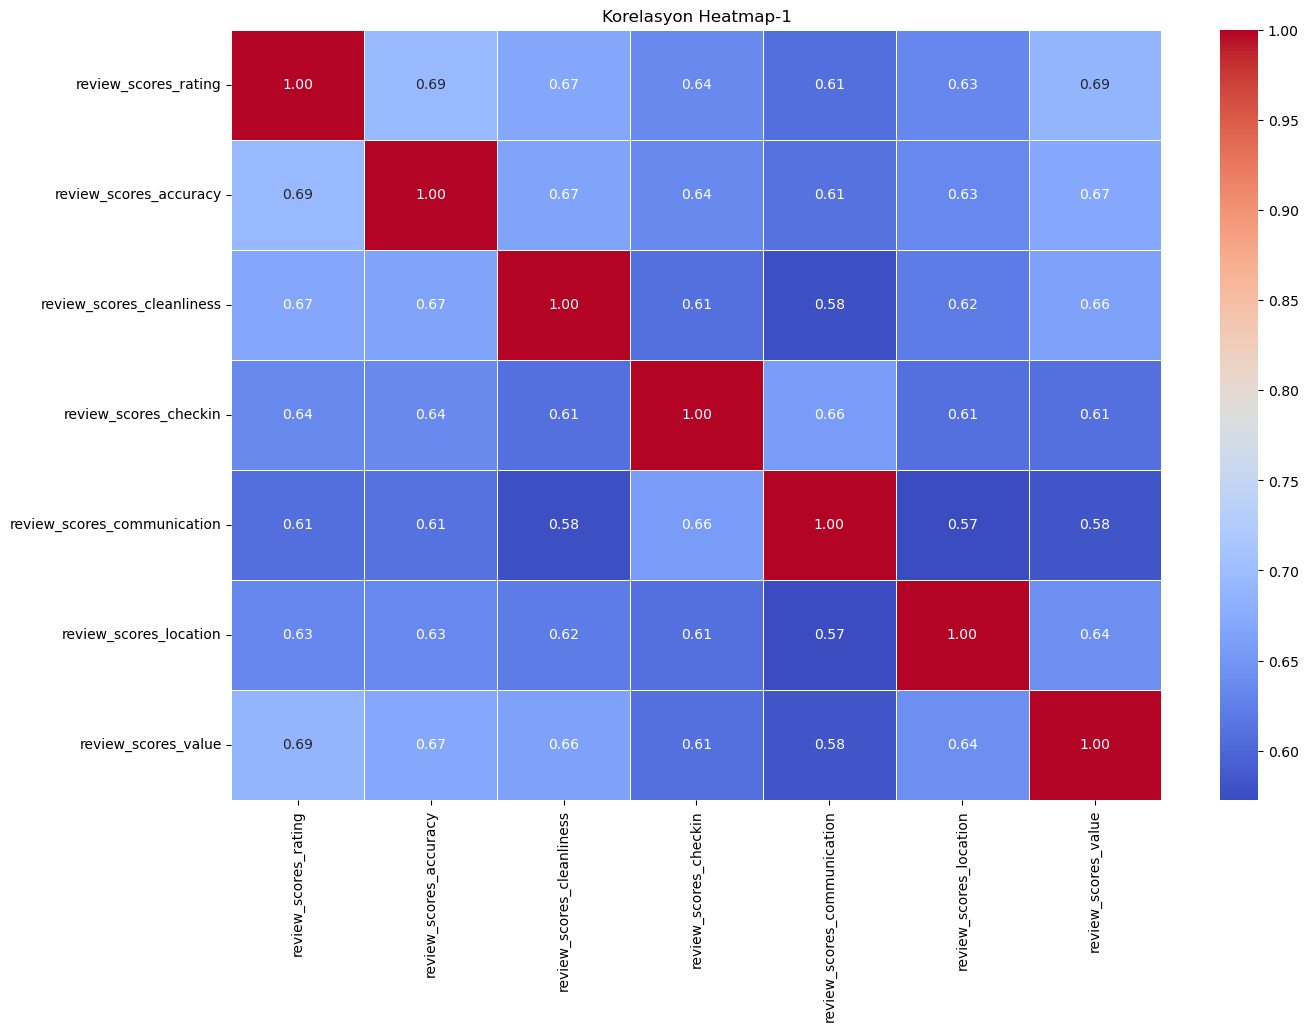

In [27]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    price_review_corr,
    annot=True,      # Korelasyon değerlerini yazar
    cmap="coolwarm", # Renk paleti
    fmt=".2f",       # Virgülden sonra 2 basamak
    linewidths=0.5
)

plt.title("Korelasyon Heatmap-1")
plt.show()

In [28]:
secilmis_col=["accommodates",
"bathrooms",
"bedrooms",
"beds",
"minimum_nights",
"availability_365",
"reviews_per_month",
"review_scores_rating"]

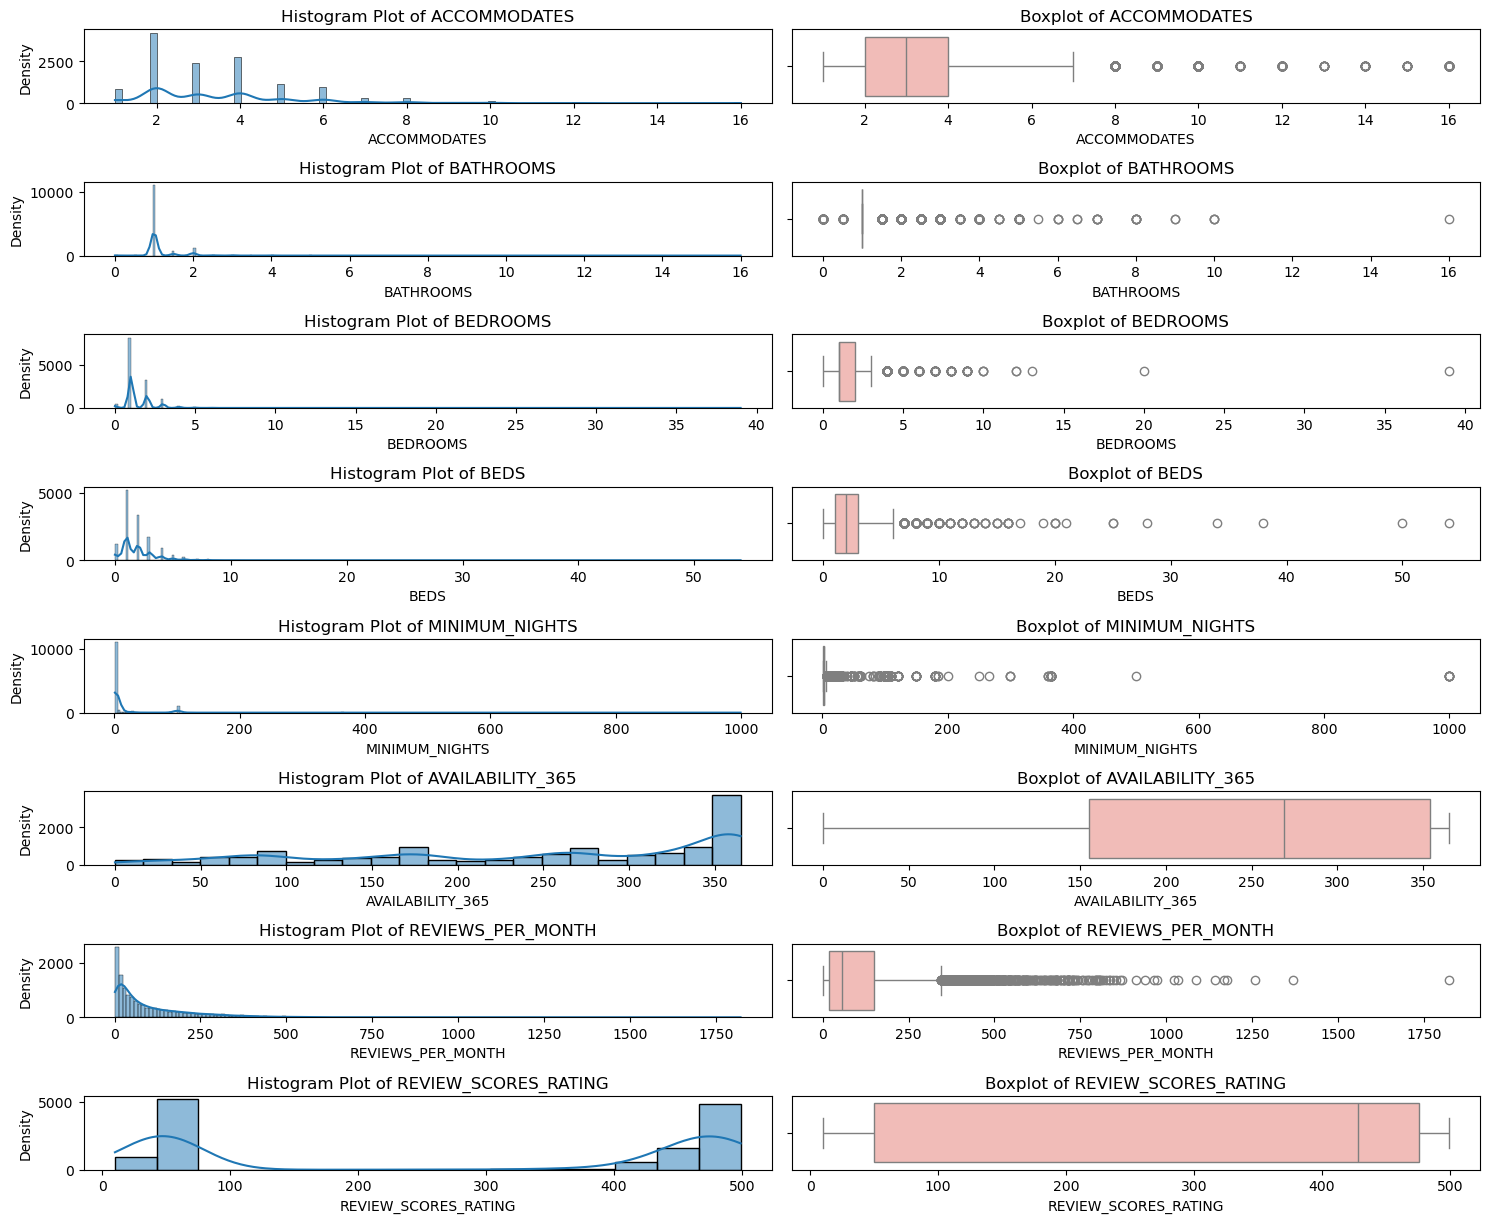

In [29]:
plt.figure(figsize=(15, 18))
for i, col in enumerate(secilmis_col):
    # Distribution
    plt.subplot(12, 2, 2*i+1)   
    sns.histplot(df_temizlenmis[col], kde=True, palette='Pastel1')
    plt.xlabel(f"{col.upper()}")
    plt.ylabel('Density')
    plt.title(f"Histogram Plot of {col.upper()}")
    plt.tight_layout()
    
    # Boxplot
    plt.subplot(12, 2, 2*i+2)   
    sns.boxplot(df_temizlenmis[col], orient='h', palette='Pastel1')
    plt.xlabel(f"{col.upper()}")
    plt.title(f"Boxplot of {col.upper()}")
plt.show()

In [30]:
print("max bathrooms sayısı:",df_temizlenmis["bathrooms"].max())
print("min bathrooms sayısı:",df_temizlenmis["bathrooms"].min())

max bathrooms sayısı: 16.0
min bathrooms sayısı: 0.0


In [31]:
print("max bedrooms sayısı:",df_temizlenmis["bedrooms"].max())
print("min bedrooms sayısı:",df_temizlenmis["bedrooms"].min())

max bedrooms sayısı: 39
min bedrooms sayısı: 0


In [32]:
df_temizlenmis[["beds","bedrooms","bathrooms"]].head()

,beds,bedrooms,bathrooms
0,3,3,1.5
1,2,1,1.0
2,4,2,2.0
3,4,2,1.0
4,2,1,1.0


In [33]:
df_temizlenmis.shape

(13341, 44)

In [34]:
df_temizlenmis.groupby(["accommodates"]).agg({"bedrooms":"max"})

,bedrooms
accommodates,
1,9
2,10
3,39
4,12
5,5
6,10
7,7
8,5
9,7


In [35]:
df_temizlenmis.groupby(["bedrooms"]).agg({"beds":"max"})

,beds
bedrooms,
0,8
1,50
2,20
3,14
4,16
5,38
6,14
7,16
8,28


In [36]:
print(" max minumum_nights sayısı:",df_temizlenmis["minimum_nights"].max())
print("min minumum_nights sayısı:",df_temizlenmis["minimum_nights"].min())

 max minumum_nights sayısı: 999
min minumum_nights sayısı: 1


In [37]:
df_temizlenmis["minimum_nights"].describe([0.1, 0.5, 0.75, 0.80, 0.85, 0.88, 0.90, 0.95]).T

count    13341.000000
mean        13.236264
std         40.293235
min          1.000000
10%          1.000000
50%          2.000000
75%          3.000000
80%          5.000000
85%          7.000000
88%         15.000000
90%         30.000000
95%        101.000000
max        999.000000
Name: minimum_nights, dtype: float64

In [38]:
df_temizlenmis["beds"].describe([0.1, 0.5, 0.75, 0.90, 0.95, 0.98, 0.99]).T

count    13341.000000
mean         1.990480
std          1.845246
min          0.000000
10%          1.000000
50%          2.000000
75%          3.000000
90%          4.000000
95%          5.000000
98%          6.000000
99%          8.000000
max         54.000000
Name: beds, dtype: float64

In [39]:
# %85'lık değeri hesapla
up_limit = df_temizlenmis["minimum_nights"].quantile(0.85)
# %85'in üzerindeki değerleri %85 değerine eşitle (baskılama)
df_temizlenmis.loc[df_temizlenmis["minimum_nights"] > up_limit, "minimum_nights"] = up_limit

In [40]:
# %85'in üzerindeki değerleri %85 değerine eşitle (baskılama)
#df.loc[df_temizlenmis["minimum_nights"] > up_limit, "minimum_nights"] = up_limit

In [41]:
df_temizlenmis["minimum_nights"].describe([0.1, 0.5, 0.75, 0.80, 0.85, 0.88, 0.90, 0.95]).T

count    13341.000000
mean         2.878645
std          2.118642
min          1.000000
10%          1.000000
50%          2.000000
75%          3.000000
80%          5.000000
85%          7.000000
88%          7.000000
90%          7.000000
95%          7.000000
max          7.000000
Name: minimum_nights, dtype: float64

## Feature Engineering 

In [42]:
df_temizlenmis["last_review"].max()

Timestamp('2024-06-30 00:00:00')

In [43]:
## Zaman endeksli özellik üretmek üzerinden gidelim (Son yorum tarihi +1 gün olarak alınmıştır. )
ref_date = pd.to_datetime('2024-07-01')

In [44]:
df_temizlenmis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13341 entries, 0 to 13340
Data columns (total 44 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Unnamed: 0                                    13341 non-null  int64         
 1   id                                            13341 non-null  int64         
 2   host_id                                       13341 non-null  int64         
 3   host_name                                     13341 non-null  object        
 4   host_since                                    13341 non-null  datetime64[ns]
 5   host_location                                 13341 non-null  object        
 6   host_response_time                            13341 non-null  object        
 7   host_response_rate                            13341 non-null  int64         
 8   host_acceptance_rate                          13341 non-null  int6

In [45]:
## Ev sahibi platformda kaç yıldır var (güven)
df_temizlenmis['host_years_active'] = (ref_date - df_temizlenmis['host_since']).dt.days / 365

In [46]:
df_temizlenmis['host_years_active'].mean()

np.float64(5.724365818421531)

In [47]:
## İlana son yorum yapılmasından bu yana geçen gün sayısı(recency)
df_temizlenmis['days_since_last_review'] = (ref_date - df_temizlenmis['last_review']).dt.days

In [48]:
## İlanın ilk yorumu ile son yorumu arasındaki süre (ilanın aktif yaşı)
df_temizlenmis['listing_age_days'] = (df_temizlenmis['last_review'] - df_temizlenmis['first_review']).dt.days

In [49]:
df_temizlenmis['listing_age_days'].min()

0

In [50]:
### Ratio Features ##

In [51]:
# Kişi başı fiyat
df_temizlenmis['price_per_accommodate'] =df_temizlenmis['price'] / df_temizlenmis['accommodates'].replace(0, np.nan)

In [52]:
## Oda başına düşen yatak sayısı (bize konfor ve imkan ile ilgili fikir verir)
##df_temizlenmis['beds_per_bedroom'] = df_temizlenmis['beds'] / df_temizlenmis['bedrooms'].replace(0, np.nan)

In [53]:
## Yıllık doluluk oranı (ciro hesaplamada fikir verir )
df_temizlenmis['occupancy_rate_365'] = (365 - df_temizlenmis['availability_365']) / 365.0

In [54]:
## Yıllık ciro/gelir hesaplama (gelir için fikir verir)
df_temizlenmis['est_annual_revenue'] = df_temizlenmis['price'] * (365 - df_temizlenmis['availability_365'])

In [55]:
## Aggregation Features ###

In [56]:
# Lokasyon endeksli ortalama fiyatlar (bulunduğu yerdeki ortalama fiyatlara göre ) 
#price sütnunu tamamen değiştirecek mi?
#neigh_avg_price = df_temizlenmis.groupby('neighbourhood_cleansed')['price'].transform('mean')
#df_temizlenmis['price_to_neigh_avg'] = df_temizlenmis['price'] / neigh_avg_price

In [57]:
# Oda tarzı endeksli ortalama fiyatlar (aynı oda tipi ortalama fiyatlara göre )
#room_avg_price = df.groupby('room_type')['price'].transform('mean')
#df['price_to_roomtype_avg'] = df['price'] / room_avg_price

In [58]:
df_temizlenmis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13341 entries, 0 to 13340
Data columns (total 50 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Unnamed: 0                                    13341 non-null  int64         
 1   id                                            13341 non-null  int64         
 2   host_id                                       13341 non-null  int64         
 3   host_name                                     13341 non-null  object        
 4   host_since                                    13341 non-null  datetime64[ns]
 5   host_location                                 13341 non-null  object        
 6   host_response_time                            13341 non-null  object        
 7   host_response_rate                            13341 non-null  int64         
 8   host_acceptance_rate                          13341 non-null  int6

In [59]:
df_temizlenmis['review_activty']=df_temizlenmis["number_of_reviews"] / df_temizlenmis["host_years_active"]

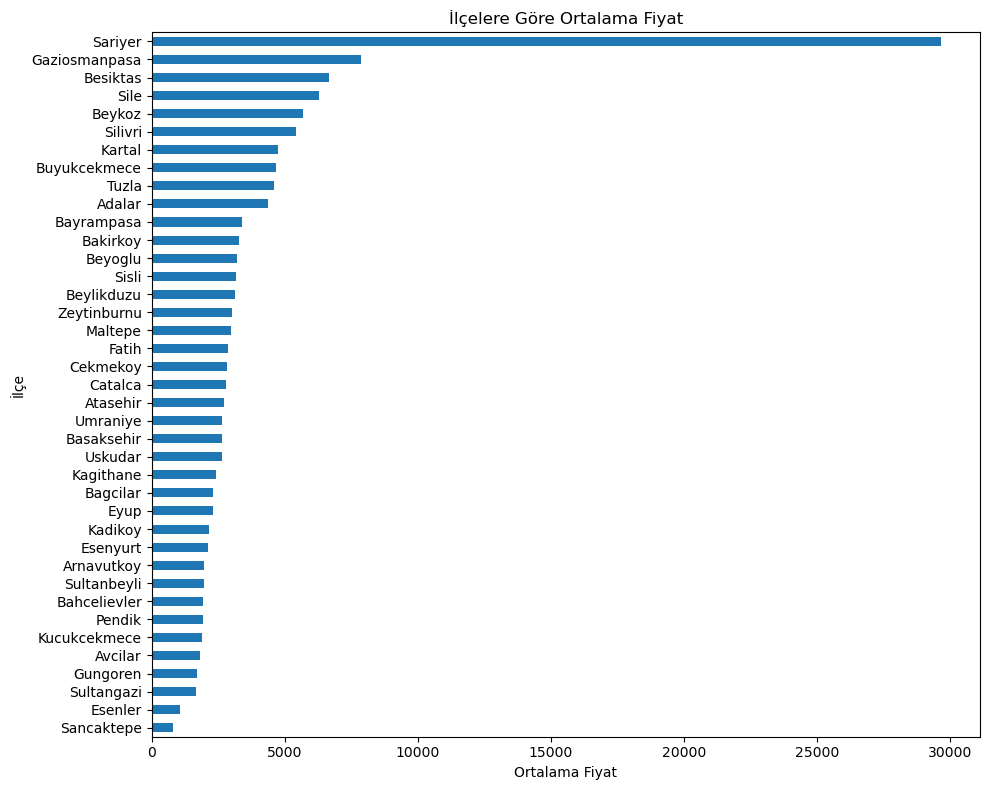

In [60]:


avg_price = (df_temizlenmis.groupby("neighbourhood_cleansed")["price"].mean().sort_values())

plt.figure(figsize=(10,8))
avg_price.plot(kind="barh")

plt.title("İlçelere Göre Ortalama Fiyat")
plt.xlabel("Ortalama Fiyat")
plt.ylabel("İlçe")

plt.tight_layout()
plt.show()

In [61]:
df_temizlenmis[["price"]].describe([0.05,0.1, 0.5, 0.75, 0.80, 0.85, 0.88, 0.90, 0.95, 0.98, 0.99]).T.style.format("{:.2f}")

,count,mean,std,min,5%,10%,50%,75%,80%,85%,88%,90%,95%,98%,99%,max
price,13341.00,3473.67,38798.37,135.00,641.00,889.00,2099.00,3259.00,3649.00,4272.00,4857.40,5258.00,7360.00,11102.60,16432.00,3310226.00


In [62]:
df_temizlenmis["price"].head()

0    3522
1    1315
2    3874
3    2136
4    1338
Name: price, dtype: int64

In [63]:
df_temizlenmis.isnull().sum()

Unnamed: 0                                      0
id                                              0
host_id                                         0
host_name                                       0
host_since                                      0
host_location                                   0
host_response_time                              0
host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_identity_verified                          0
neighbourhood_cleansed                          0
property_type                                   0
room_type                                       0
accommodates                                    0
bathrooms                                       0
bedrooms                                        0
beds                                            0
price                                           0
minimum_nights                                  0


In [64]:
#price değeri içinde bulunan 
df_temizlenmis = df_temizlenmis.drop(df_temizlenmis['price'].idxmax())

In [65]:
df_temizlenmis["price"].max()

2954000

In [66]:
neighbourhood_summary = df_temizlenmis.groupby("neighbourhood_cleansed").agg({
    "price": "mean",
    "reviews_per_month": "mean",
    "availability_365": "mean",
    "review_scores_rating": "mean",
    "est_annual_revenue": "mean"}).sort_values("est_annual_revenue")

In [67]:
neighbourhood_summary

,price,reviews_per_month,availability_365,review_scores_rating,est_annual_revenue
neighbourhood_cleansed,,,,,
Sancaktepe,794.600000,29.200000,260.600000,49.000000,84091.600000
Bayrampasa,3382.222222,59.000000,264.777778,325.444444,138319.333333
Sultanbeyli,1951.000000,27.600000,266.400000,50.000000,147764.800000
Bahcelievler,1945.059459,50.648649,277.778378,152.578378,172875.297297
Arnavutkoy,1962.467532,122.649351,262.428571,238.415584,177882.428571
Esenler,1081.857143,67.785714,194.928571,226.000000,195988.357143
Atasehir,2703.307359,59.116883,286.216450,208.424242,207272.194805
Kucukcekmece,1905.857143,48.702381,265.976190,161.202381,212443.404762
Umraniye,2661.000000,46.758621,247.252874,159.816092,230876.000000


In [68]:
neighbourhood_avg=df_temizlenmis.groupby(["neighbourhood_cleansed"]).agg({"price": "mean"}).sort_values("price", ascending=False)
neighbourhood_avg

,price
neighbourhood_cleansed,
Gaziosmanpasa,7871.266667
Besiktas,6648.975207
Sile,6289.094340
Beykoz,5705.575758
Silivri,5407.666667
Kartal,4736.974026
Buyukcekmece,4689.063830
Tuzla,4581.580645
Adalar,4383.557047


In [69]:
neighbourhood_group = pd.qcut( neighbourhood_avg["price"], q=4, labels=["Düşük", "Orta", "Yüksek", "Lüks"])
neighbourhood_group

neighbourhood_cleansed
Gaziosmanpasa      Lüks
Besiktas           Lüks
Sile               Lüks
Beykoz             Lüks
Silivri            Lüks
Kartal             Lüks
Buyukcekmece       Lüks
Tuzla              Lüks
Adalar             Lüks
Sariyer            Lüks
Bayrampasa       Yüksek
Bakirkoy         Yüksek
Beyoglu          Yüksek
Sisli            Yüksek
Beylikduzu       Yüksek
Zeytinburnu      Yüksek
Maltepe          Yüksek
Fatih            Yüksek
Cekmekoy         Yüksek
Catalca            Orta
Atasehir           Orta
Umraniye           Orta
Basaksehir         Orta
Uskudar            Orta
Kagithane          Orta
Bagcilar           Orta
Eyup               Orta
Kadikoy            Orta
Esenyurt           Orta
Arnavutkoy        Düşük
Sultanbeyli       Düşük
Bahcelievler      Düşük
Pendik            Düşük
Kucukcekmece      Düşük
Avcilar           Düşük
Gungoren          Düşük
Sultangazi        Düşük
Esenler           Düşük
Sancaktepe        Düşük
Name: price, dtype: category
Categories (

In [70]:
df_temizlenmis["neighbourhood_group"] = (df_temizlenmis["neighbourhood_cleansed"].map(neighbourhood_group))

In [71]:
df_temizlenmis.head(20)

,Unnamed: 0,id,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,calculated_host_listings_count_shared_rooms,reviews_per_month,host_years_active,days_since_last_review,listing_age_days,price_per_accommodate,occupancy_rate_365,est_annual_revenue,review_activty,neighbourhood_group
0,0,607344,2751565,Volkan,2012-06-26,"İstanbul, Turkey",within an hour,100,100,t,...,0,44,12.021918,6,4107,880.500000,0.098630,126792,5.074066,Yüksek
1,1,34177,147330,Ercan,2010-06-18,"Istanbul, Turkey",within an hour,100,55,t,...,0,15,14.046575,180,2927,438.333333,0.493151,236700,1.139068,Lüks
2,2,612327,2911496,Nadira,2012-07-12,"Paris, France",within a few hours,100,89,t,...,0,208,11.978082,10,4332,645.666667,0.019178,27118,25.129231,Yüksek
3,4,630800,485384,Alev,2011-04-05,"Istanbul, Turkey",within an hour,100,100,t,...,0,68,13.249315,29,4269,534.000000,0.263014,205056,7.321133,Yüksek
4,5,73477,383789,Berat,2011-02-09,"İstanbul, Turkey",within an hour,100,90,t,...,0,38,13.400000,170,696,669.000000,0.087671,42816,0.820896,Yüksek
5,6,632120,3144818,Semih,2012-08-03,"Istanbul, Turkey",within a few hours,90,33,f,...,0,1,11.917808,588,3728,1798.000000,0.753425,988900,1.258621,Yüksek
6,7,77292,414003,Omer Faruk,2011-02-28,"İstanbul, Turkey",within a day,50,64,f,...,0,28,13.347945,77,1335,1173.833333,0.169863,436666,0.973933,Yüksek
7,8,638542,2618254,Dodo,2012-06-12,"İstanbul, Turkey",within an hour,100,100,t,...,0,195,12.060274,9,4295,1404.250000,0.690411,2830968,23.216720,Yüksek
8,9,639951,3195183,Efe & Memet,2012-08-08,"İstanbul, Turkey",within an hour,100,100,t,...,0,68,11.904110,47,4258,536.666667,0.142466,83720,8.148446,Lüks
9,10,88949,485384,Alev,2011-04-05,"Istanbul, Turkey",within an hour,100,100,t,...,0,7,13.249315,178,4616,1027.000000,0.002740,4108,8.453267,Yüksek


In [72]:
##################################
# AYKIRI DEĞER ANALİZİ 
##################################

def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit
    
#def check_outlier(dataframe, col_name):
    #low_limit, up_limit = outlier_thresholds(dataframe, col_name)
   # if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
      #  return True
    #else:
        #return False

def check_outlier(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    iqr = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * iqr
    low_limit = quartile1 - 1.5 * iqr
    return dataframe.loc[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit), col_name].any()

def replace_with_thresholds(dataframe, variable, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1=0.05, q3=0.95)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit


In [73]:
df_temizlenmis["host_id"] = df_temizlenmis["host_id"].astype("object")
df_temizlenmis["id"] = df_temizlenmis["id"].astype("object")

In [74]:
outlier_cols=["accommodates",'bedrooms', 'beds', 'price']
df_temizlenmis[outlier_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 13340 entries, 0 to 13340
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   accommodates  13340 non-null  int64
 1   bedrooms      13340 non-null  int64
 2   beds          13340 non-null  int64
 3   price         13340 non-null  int64
dtypes: int64(4)
memory usage: 521.1 KB


In [75]:
for col in outlier_cols:
    print(col, check_outlier(df_temizlenmis[outlier_cols], col))

accommodates True
bedrooms True
beds True
price True


In [76]:
def grab_outliers(dataframe, col_name, index=False):
    quartile1 = dataframe[col_name].quantile(0.25)
    quartile3 = dataframe[col_name].quantile(0.75)
    iqr = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * iqr
    low_limit = quartile1 - 1.5 * iqr

    outliers = dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)]
    print(col_name, "-> outlier sayısı:", outliers.shape[0])
    print(outliers[col_name].describe())

    if index:
        return outliers.index

for col in outlier_cols:
    grab_outliers(df_temizlenmis, col)
    print("-" * 40)

accommodates -> outlier sayısı: 664
count    664.000000
mean       9.813253
std        2.448518
min        8.000000
25%        8.000000
50%        9.000000
75%       10.000000
max       16.000000
Name: accommodates, dtype: float64
----------------------------------------
bedrooms -> outlier sayısı: 396
count    396.000000
mean       4.954545
std        2.394710
min        4.000000
25%        4.000000
50%        4.000000
75%        5.000000
max       39.000000
Name: bedrooms, dtype: float64
----------------------------------------
beds -> outlier sayısı: 260
count    260.000000
mean       9.634615
std        5.484372
min        7.000000
25%        7.000000
50%        8.000000
75%       10.000000
max       54.000000
Name: beds, dtype: float64
----------------------------------------
price -> outlier sayısı: 1022
count    1.022000e+03
mean     1.532948e+04
std      9.370391e+04
min      6.070000e+03
25%      6.973500e+03
50%      8.300500e+03
75%      1.150300e+04
max      2.954000e+06
Na

In [77]:
cols_to_cap = ["bedrooms", "beds"]

for col in cols_to_cap:
    replace_with_thresholds(df_temizlenmis, col)

# kontrol
for col in cols_to_cap:
    print(col, check_outlier(df_temizlenmis[outlier_cols], col))

bedrooms True
beds True


In [78]:
df_temizlenmis["beds"].max()

12.5

In [79]:
df_temizlenmis[outlier_cols].sort_values("price", ascending=False).head(20)

,accommodates,bedrooms,beds,price
8890,3,1,1.0,2954000
4847,1,2,2.0,288570
12698,3,1,1.0,177097
13085,7,4,4.0,177097
13307,5,2,2.0,177097
3062,9,3,7.0,164323
2037,2,1,2.0,122901
2230,2,1,3.0,122901
2035,2,1,2.0,122901
2027,2,1,2.0,122901


In [80]:
# 1. Numerik (int64 ve float64) sütunları otomatik seçer
num_cols=df_temizlenmis.select_dtypes(include=['number']).columns.tolist()

# 2. Kategorik (object veya category) sütunları otomatik seçer
kategorik_kolonlar = df_temizlenmis.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerik Sütunlar:", num_cols)
print("Kategorik Sütunlar:", kategorik_kolonlar)

Numerik Sütunlar: ['Unnamed: 0', 'host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'host_years_active', 'days_since_last_review', 'listing_age_days', 'price_per_accommodate', 'occupancy_rate_365', 'est_annual_revenue', 'review_activty']
Kategorik Sütunlar: ['id', 'host_id', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'host_identity_verified', 'neigh

In [81]:
df_temizlenmis[["accommodates","bathrooms","bedrooms", "beds", "price"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 13340 entries, 0 to 13340
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   accommodates  13340 non-null  int64  
 1   bathrooms     13340 non-null  float64
 2   bedrooms      13340 non-null  int64  
 3   beds          13340 non-null  float64
 4   price         13340 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 625.3 KB


In [82]:
df_temizlenmis.loc[df_temizlenmis["price"] == 2954000, "price"] = 288570

In [83]:
df_temizlenmis[outlier_cols].sort_values("price", ascending=False).head(5)

,accommodates,bedrooms,beds,price
8890,3,1,1.0,288570
4847,1,2,2.0,288570
12698,3,1,1.0,177097
13085,7,4,4.0,177097
13307,5,2,2.0,177097


In [84]:
#df_temizlenmis=df_temizlenmis.drop(['id','host_id',"host_name"],axis=1)

In [85]:
# Yeni üretilen değişkenler için cat, num ayırımını tekrar yapalım.
cat_cols = [col for col in df_temizlenmis.columns if df_temizlenmis[col].dtypes == "O"]
num_cols = [col for col in df_temizlenmis.columns if df_temizlenmis[col].dtypes != "O"]
binary_cols = [col for col in df_temizlenmis.columns if df_temizlenmis[col].dtypes == "O" and df_temizlenmis[col].nunique() == 2]
binary_cols

['host_is_superhost', 'host_identity_verified', 'instant_bookable']

In [86]:
cat_cols

['id',
 'host_id',
 'host_name',
 'host_location',
 'host_response_time',
 'host_is_superhost',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'property_type',
 'room_type',
 'has_availability',
 'instant_bookable']

In [87]:
num_cols

['Unnamed: 0',
 'host_since',
 'host_response_rate',
 'host_acceptance_rate',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'host_years_active',
 'days_since_last_review',
 'listing_age_days',
 'price_per_accommodate',
 'occupancy_rate_365',
 'est_annual_revenue',
 'review_activty',
 'neighbourhood_group']

In [88]:
!pip3 install catboost
!pip install xgboost
!pip install lightgbm

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression  #1
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, cross_validate

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier     #2
from sklearn.svm import SVC
from catboost import CatBoostClassifier       #3
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [90]:
# Binary kolonlar label encoder yapacağız.
labelencoder = LabelEncoder()

In [91]:
for col in binary_cols:
    labelencoder = LabelEncoder()
    df_temizlenmis[col] = labelencoder.fit_transform(df_temizlenmis[col])

In [92]:
df_temizlenmis[binary_cols]

,host_is_superhost,host_identity_verified,instant_bookable
0,1,1,1
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
...,...,...,...
13336,0,1,0
13337,0,1,1
13338,0,1,1
13339,1,1,1


In [93]:
df["property_type"]

0        Entire serviced apartment
1                      Entire home
2                     Entire condo
3               Entire rental unit
4               Entire rental unit
                   ...            
19397    Entire serviced apartment
19398           Entire rental unit
19399           Entire rental unit
19400           Entire rental unit
19401           Entire rental unit
Name: property_type, Length: 19402, dtype: object

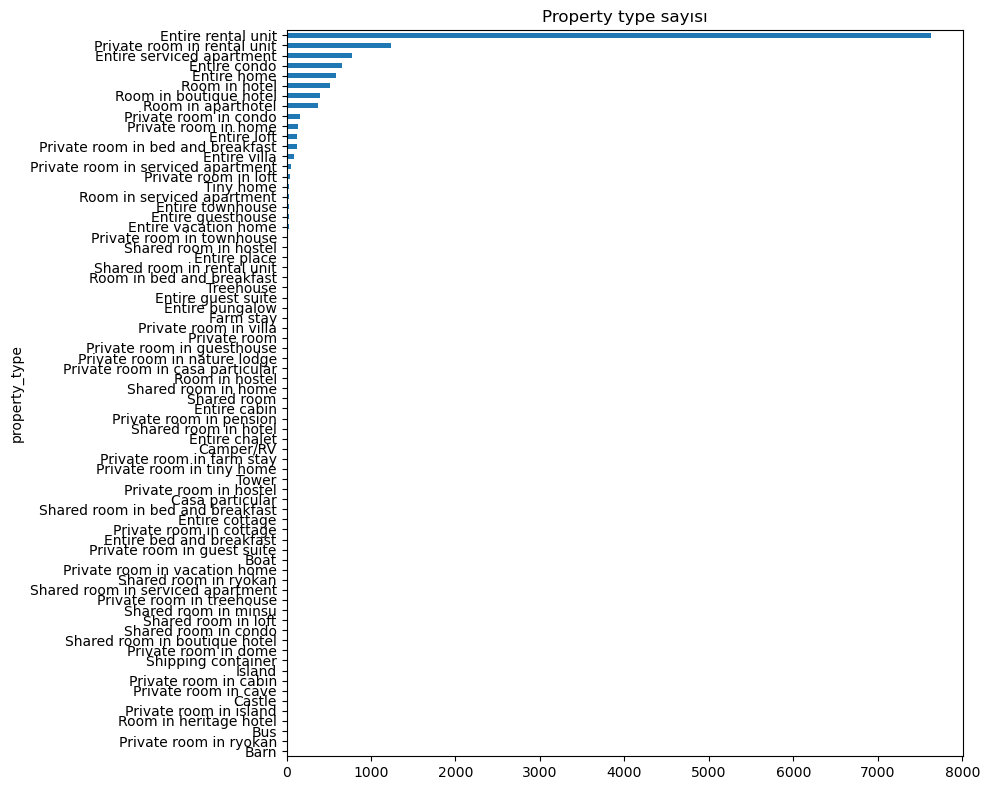

In [94]:
#gruplayabilmek için property_type bazında sayı grafiği 
property_type_count = (df_temizlenmis.groupby("property_type")["property_type"].count().sort_values())

plt.figure(figsize=(10,8))
property_type_count.plot(kind="barh")

plt.title("Property type sayısı")
#plt.xlabel("Ortalama Fiyat")
#plt.ylabel("İlçe")

plt.tight_layout()
plt.show()

In [95]:
# Eşik: "Entire villa" kategorisinin frekansı
counts = df_temizlenmis["property_type"].value_counts()
threshold = counts["Entire villa"]

# Bu eşiğin altında kalan kategorileri bul
rare_categories = counts[counts <= threshold].index

# Bu kategorileri "Other" ile değiştir
df_temizlenmis["property_type"] = df_temizlenmis["property_type"].apply(
    lambda x: "Other" if x in rare_categories else x)

In [96]:
df_temizlenmis["property_type"].value_counts()

property_type
Entire rental unit                   7628
Private room in rental unit          1233
Entire serviced apartment             775
Entire condo                          661
Other                                 636
Entire home                           581
Room in hotel                         515
Room in boutique hotel                393
Room in aparthotel                    373
Private room in condo                 154
Private room in home                  141
Entire loft                           126
Private room in bed and breakfast     124
Name: count, dtype: int64

In [97]:
mapping = {
    "Entire rental unit": "Rental unit",
    "Private room in rental unit": "Rental unit",
    "Entire serviced apartment": "Apartment",
    "Entire condo": "Apartment",
    "Private room in condo": "Apartment",
    "Entire home": "Home",
    "Private room in home": "Home",
    "Room in hotel": "Hotel",
    "Room in boutique hotel": "Hotel",
    "Room in aparthotel": "Hotel",
    "Entire loft": "Other_type",
    "Private room in bed and breakfast": "Other_type",
    "Entire villa": "Other_type",
    "Other": "Other_type",
}

df_temizlenmis["property_type_grouped"] = df_temizlenmis["property_type"].map(mapping)
df_temizlenmis["property_type_grouped"].value_counts()

property_type_grouped
Rental unit    8861
Apartment      1590
Hotel          1281
Other_type      886
Home            722
Name: count, dtype: int64

In [98]:
df_temizlenmis["property_type"].map(mapping)

0          Apartment
1               Home
2          Apartment
3        Rental unit
4        Rental unit
            ...     
13336      Apartment
13337    Rental unit
13338    Rental unit
13339    Rental unit
13340    Rental unit
Name: property_type, Length: 13340, dtype: object

In [99]:
df_temizlenmis.head()

,Unnamed: 0,id,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,reviews_per_month,host_years_active,days_since_last_review,listing_age_days,price_per_accommodate,occupancy_rate_365,est_annual_revenue,review_activty,neighbourhood_group,property_type_grouped
0,0,607344,2751565,Volkan,2012-06-26,"İstanbul, Turkey",within an hour,100,100,1,...,44,12.021918,6,4107,880.500000,0.098630,126792,5.074066,Yüksek,Apartment
1,1,34177,147330,Ercan,2010-06-18,"Istanbul, Turkey",within an hour,100,55,1,...,15,14.046575,180,2927,438.333333,0.493151,236700,1.139068,Lüks,Home
2,2,612327,2911496,Nadira,2012-07-12,"Paris, France",within a few hours,100,89,1,...,208,11.978082,10,4332,645.666667,0.019178,27118,25.129231,Yüksek,Apartment
3,4,630800,485384,Alev,2011-04-05,"Istanbul, Turkey",within an hour,100,100,1,...,68,13.249315,29,4269,534.000000,0.263014,205056,7.321133,Yüksek,Rental unit
4,5,73477,383789,Berat,2011-02-09,"İstanbul, Turkey",within an hour,100,90,1,...,38,13.400000,170,696,669.000000,0.087671,42816,0.820896,Yüksek,Rental unit


In [100]:
df_temizlenmis.isnull().sum()

Unnamed: 0                                      0
id                                              0
host_id                                         0
host_name                                       0
host_since                                      0
host_location                                   0
host_response_time                              0
host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_identity_verified                          0
neighbourhood_cleansed                          0
property_type                                   0
room_type                                       0
accommodates                                    0
bathrooms                                       0
bedrooms                                        0
beds                                            0
price                                           0
minimum_nights                                  0


In [101]:
sira = {"Düşük": 0, "Orta": 1, "Yüksek": 2, "Lüks": 3}
df_temizlenmis["neighbourhood_group_encoded"] = df_temizlenmis["neighbourhood_group"].map(sira)

In [102]:
df_temizlenmis["neighbourhood_group"].dtype

CategoricalDtype(categories=['Düşük', 'Orta', 'Yüksek', 'Lüks'], ordered=True, categories_dtype=object)

In [103]:
df_temizlenmis["neighbourhood_group_encoded"] = df_temizlenmis["neighbourhood_group"].cat.codes

In [104]:
df_temizlenmis["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Beyoglu          4250
Fatih            1802
Sisli            1793
Kadikoy          1183
Besiktas          847
Uskudar           329
Kagithane         302
Esenyurt          298
Bagcilar          232
Atasehir          231
Bahcelievler      185
Maltepe           163
Sile              159
Adalar            149
Bakirkoy          132
Sariyer           129
Avcilar           104
Eyup              100
Zeytinburnu        93
Pendik             90
Umraniye           87
Kucukcekmece       84
Kartal             77
Arnavutkoy         77
Beylikduzu         76
Basaksehir         68
Beykoz             66
Buyukcekmece       47
Tuzla              31
Gaziosmanpasa      30
Gungoren           30
Silivri            24
Cekmekoy           16
Catalca            16
Esenler            14
Bayrampasa          9
Sultangazi          7
Sultanbeyli         5
Sancaktepe          5
Name: count, dtype: int64

In [105]:
counts = df_temizlenmis["neighbourhood_cleansed"].value_counts()
esik = 75  # örnek eşik

az_ornekli = counts[counts < esik].index

df_temizlenmis["neighbourhood_model"] = df_temizlenmis["neighbourhood_cleansed"].apply(lambda x: "Diger" if x in az_ornekli else x)

In [106]:
df_temizlenmis.head()

,Unnamed: 0,id,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,days_since_last_review,listing_age_days,price_per_accommodate,occupancy_rate_365,est_annual_revenue,review_activty,neighbourhood_group,property_type_grouped,neighbourhood_group_encoded,neighbourhood_model
0,0,607344,2751565,Volkan,2012-06-26,"İstanbul, Turkey",within an hour,100,100,1,...,6,4107,880.500000,0.098630,126792,5.074066,Yüksek,Apartment,2,Fatih
1,1,34177,147330,Ercan,2010-06-18,"Istanbul, Turkey",within an hour,100,55,1,...,180,2927,438.333333,0.493151,236700,1.139068,Lüks,Home,3,Besiktas
2,2,612327,2911496,Nadira,2012-07-12,"Paris, France",within a few hours,100,89,1,...,10,4332,645.666667,0.019178,27118,25.129231,Yüksek,Apartment,2,Beyoglu
3,4,630800,485384,Alev,2011-04-05,"Istanbul, Turkey",within an hour,100,100,1,...,29,4269,534.000000,0.263014,205056,7.321133,Yüksek,Rental unit,2,Beyoglu
4,5,73477,383789,Berat,2011-02-09,"İstanbul, Turkey",within an hour,100,90,1,...,170,696,669.000000,0.087671,42816,0.820896,Yüksek,Rental unit,2,Beyoglu


In [107]:
#df_temizlenmis.to_excel("C:/Users/Casper/Desktop/Proje/airbnb_temizlenmis27.07.xlsx")

In [108]:
replace_with_thresholds(df_temizlenmis, "est_annual_revenue")
df_temizlenmis["est_annual_revenue"].max()

3038813.124999999

In [109]:
feature_cols = [
    "neighbourhood_model",
    "room_type",
    "property_type_grouped",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "review_scores_rating",
    "reviews_per_month",
    "host_years_active"]
model_df = df_temizlenmis[feature_cols + ["est_annual_revenue"]].dropna()
X = pd.get_dummies(df_temizlenmis[feature_cols],columns=["neighbourhood_model", "room_type", "property_type_grouped"],drop_first=True)

y = df_temizlenmis["est_annual_revenue"]

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17)

print(X_train.shape, X_test.shape)

(9338, 39) (4002, 39)


## Linear Regression Modeli

In [111]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

RMSE: 425535.3310946384
MAE: 284345.6299156313
R2: 0.1536308205965622


## RandomForestRegressor

In [112]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

RMSE: 406964.84170727164
MAE: 263596.3992848262
R2: 0.22589054032493194


## CatBoost

In [113]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(verbose=False, random_state=12345)
catboost_model.fit(X_train, y_train)
y_pred_cb = catboost_model.predict(X_test)

print("CatBoost - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_cb)))
print("CatBoost - MAE:", mean_absolute_error(y_test, y_pred_cb))
print("CatBoost - R2:", r2_score(y_test, y_pred_cb))

CatBoost - RMSE: 402559.1147872663
CatBoost - MAE: 262896.03037611366
CatBoost - R2: 0.2425605507671187


In [114]:
df_temizlenmis["revenue_category"] = pd.qcut(
    df_temizlenmis["est_annual_revenue"], 
    q=3, 
    labels=["Düşük", "Orta", "Yüksek"]
)

df_temizlenmis["revenue_category"].value_counts()

revenue_category
Düşük     4447
Yüksek    4447
Orta      4446
Name: count, dtype: int64

In [115]:
y_class = df_temizlenmis.loc[X.index, "revenue_category"]  # X ile aynı index'e hizala

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.3, random_state=17, stratify=y_class
)

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test_c, y_pred_log))
print("Precision:", precision_score(y_test_c, y_pred_log, average="weighted"))
print("Recall:", recall_score(y_test_c, y_pred_log, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_log, average="weighted"))
print(classification_report(y_test_c, y_pred_log))

Logistic Regression
Accuracy: 0.4740129935032484
Precision: 0.4693499683617454
Recall: 0.4740129935032484
F1: 0.46594816480237183
              precision    recall  f1-score   support

       Düşük       0.49      0.55      0.52      1334
        Orta       0.44      0.31      0.36      1334
      Yüksek       0.48      0.57      0.52      1334

    accuracy                           0.47      4002
   macro avg       0.47      0.47      0.47      4002
weighted avg       0.47      0.47      0.47      4002



In [117]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf = rf_clf.predict(X_test_c)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("Precision:", precision_score(y_test_c, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_test_c, y_pred_rf, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_rf, average="weighted"))
print(classification_report(y_test_c, y_pred_rf))

Random Forest
Accuracy: 0.5572213893053474
Precision: 0.5538918608635395
Recall: 0.5572213893053474
F1: 0.5538369725365259
              precision    recall  f1-score   support

       Düşük       0.58      0.62      0.60      1334
        Orta       0.51      0.43      0.47      1334
      Yüksek       0.57      0.62      0.60      1334

    accuracy                           0.56      4002
   macro avg       0.55      0.56      0.55      4002
weighted avg       0.55      0.56      0.55      4002



In [118]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_c)
y_test_enc = le.transform(y_test_c)

xgb_clf = XGBClassifier(random_state=42, eval_metric="mlogloss")
xgb_clf.fit(X_train_c, y_train_enc)
y_pred_xgb = xgb_clf.predict(X_test_c)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("Precision:", precision_score(y_test_enc, y_pred_xgb, average="weighted"))
print("Recall:", recall_score(y_test_enc, y_pred_xgb, average="weighted"))
print("F1:", f1_score(y_test_enc, y_pred_xgb, average="weighted"))
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

XGBoost
Accuracy: 0.551224387806097
Precision: 0.5477473422607825
Recall: 0.551224387806097
F1: 0.5482875299625781
              precision    recall  f1-score   support

       Düşük       0.56      0.61      0.58      1334
        Orta       0.49      0.43      0.46      1334
      Yüksek       0.59      0.62      0.60      1334

    accuracy                           0.55      4002
   macro avg       0.55      0.55      0.55      4002
weighted avg       0.55      0.55      0.55      4002



In [119]:
from catboost import CatBoostClassifier

cb_clf = CatBoostClassifier(verbose=False, random_state=12345)
cb_clf.fit(X_train_c, y_train_c)
y_pred_cb = cb_clf.predict(X_test_c)

print("CatBoost")
print("Accuracy:", accuracy_score(y_test_c, y_pred_cb))
print("Precision:", precision_score(y_test_c, y_pred_cb, average="weighted"))
print("Recall:", recall_score(y_test_c, y_pred_cb, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_cb, average="weighted"))
print(classification_report(y_test_c, y_pred_cb))

CatBoost
Accuracy: 0.5419790104947526
Precision: 0.5383492253071033
Recall: 0.5419790104947526
F1: 0.5388207388546747
              precision    recall  f1-score   support

       Düşük       0.56      0.61      0.58      1334
        Orta       0.48      0.42      0.45      1334
      Yüksek       0.57      0.60      0.58      1334

    accuracy                           0.54      4002
   macro avg       0.54      0.54      0.54      4002
weighted avg       0.54      0.54      0.54      4002



In [120]:
importances = pd.Series(rf_clf.feature_importances_, index=X_train_c.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

host_years_active                    0.218147
reviews_per_month                    0.208625
review_scores_rating                 0.153946
accommodates                         0.071595
beds                                 0.064200
bedrooms                             0.039728
bathrooms                            0.026617
room_type_Private room               0.023127
property_type_grouped_Rental unit    0.019422
neighbourhood_model_Beyoglu          0.017087
neighbourhood_model_Sisli            0.014986
neighbourhood_model_Fatih            0.013907
neighbourhood_model_Kadikoy          0.012490
neighbourhood_model_Besiktas         0.011326
property_type_grouped_Hotel          0.009208
dtype: float64


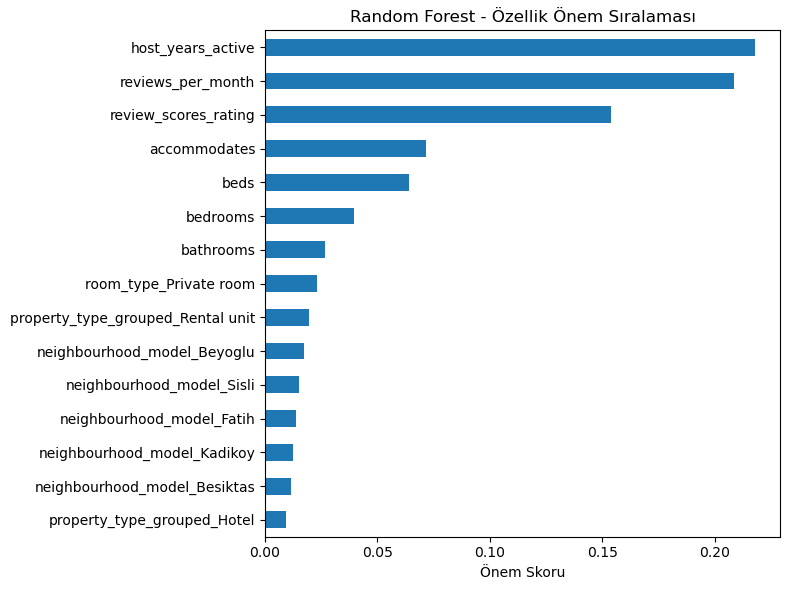

In [121]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Random Forest - Özellik Önem Sıralaması")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

In [122]:
feature_cols_purchase = [
    "neighbourhood_model",
    "room_type",
    "property_type_grouped",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "host_is_superhost"
]

X_purchase = pd.get_dummies(
    df_temizlenmis[feature_cols_purchase],
    columns=["neighbourhood_model", "room_type", "property_type_grouped"],
    drop_first=True
)

y_class_purchase = df_temizlenmis.loc[X_purchase.index, "revenue_category"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_purchase, y_class_purchase, test_size=0.3, random_state=17, stratify=y_class_purchase
)

rf_clf_purchase = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_clf_purchase.fit(X_train_p, y_train_p)
y_pred_p = rf_clf_purchase.predict(X_test_p)

print("Accuracy:", accuracy_score(y_test_p, y_pred_p))
print("Precision:", precision_score(y_test_p, y_pred_p, average="weighted"))
print("Recall:", recall_score(y_test_p, y_pred_p, average="weighted"))
print("F1:", f1_score(y_test_p, y_pred_p, average="weighted"))
print(classification_report(y_test_p, y_pred_p))

Accuracy: 0.4920039980009995
Precision: 0.49027076172610795
Recall: 0.4920039980009995
F1: 0.4906919446173245
              precision    recall  f1-score   support

       Düşük       0.50      0.52      0.51      1334
        Orta       0.45      0.41      0.43      1334
      Yüksek       0.53      0.54      0.54      1334

    accuracy                           0.49      4002
   macro avg       0.49      0.49      0.49      4002
weighted avg       0.49      0.49      0.49      4002



In [123]:
importances_p = pd.Series(rf_clf_purchase.feature_importances_, index=X_train_p.columns)
importances_p = importances_p.sort_values(ascending=False)
print(importances_p.head(15))

beds                                 0.185129
accommodates                         0.183867
bedrooms                             0.089017
bathrooms                            0.074548
host_is_superhost                    0.047912
room_type_Private room               0.044997
property_type_grouped_Rental unit    0.038138
neighbourhood_model_Beyoglu          0.025166
neighbourhood_model_Fatih            0.021969
neighbourhood_model_Sisli            0.021628
property_type_grouped_Home           0.021384
neighbourhood_model_Kadikoy          0.019550
property_type_grouped_Other_type     0.018735
neighbourhood_model_Besiktas         0.018189
property_type_grouped_Hotel          0.018006
dtype: float64


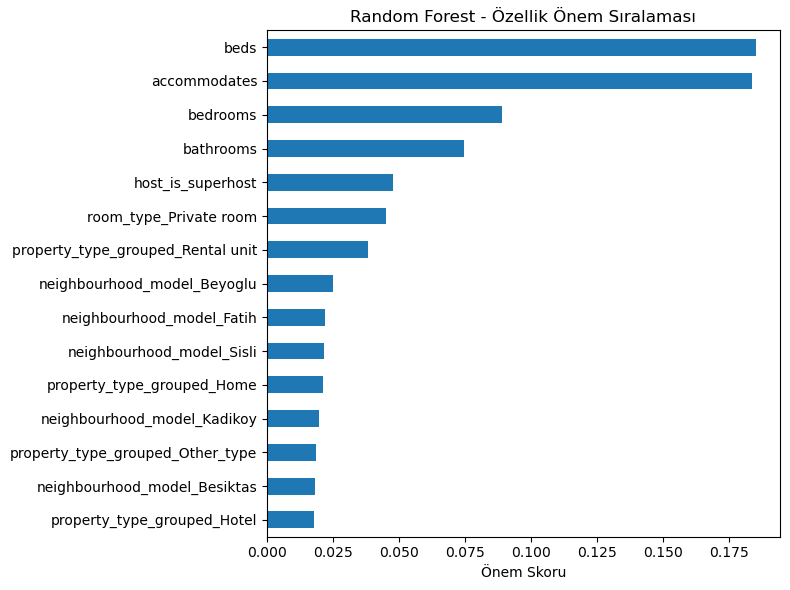

In [124]:
import matplotlib.pyplot as plt

importances_p.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Random Forest - Özellik Önem Sıralaması")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

In [125]:
neighbourhood_revenue = pd.crosstab(
    df_temizlenmis["neighbourhood_model"],
    df_temizlenmis["revenue_category"],
    normalize="index"
)

neighbourhood_revenue = neighbourhood_revenue.sort_values("Yüksek", ascending=False)
print(neighbourhood_revenue)

revenue_category        Düşük      Orta    Yüksek
neighbourhood_model                              
Sile                 0.245283  0.106918  0.647799
Adalar               0.167785  0.268456  0.563758
Zeytinburnu          0.247312  0.279570  0.473118
Beyoglu              0.278353  0.315294  0.406353
Sariyer              0.372093  0.263566  0.364341
Besiktas             0.332940  0.308146  0.358914
Avcilar              0.307692  0.346154  0.346154
Eyup                 0.330000  0.330000  0.340000
Sisli                0.354155  0.308422  0.337423
Beylikduzu           0.328947  0.342105  0.328947
Bagcilar             0.353448  0.331897  0.314655
Diger                0.380435  0.307065  0.312500
Kadikoy              0.327980  0.381234  0.290786
Bakirkoy             0.431818  0.280303  0.287879
Umraniye             0.390805  0.321839  0.287356
Uskudar              0.373860  0.349544  0.276596
Kucukcekmece         0.559524  0.190476  0.250000
Kagithane            0.364238  0.387417  0.248344


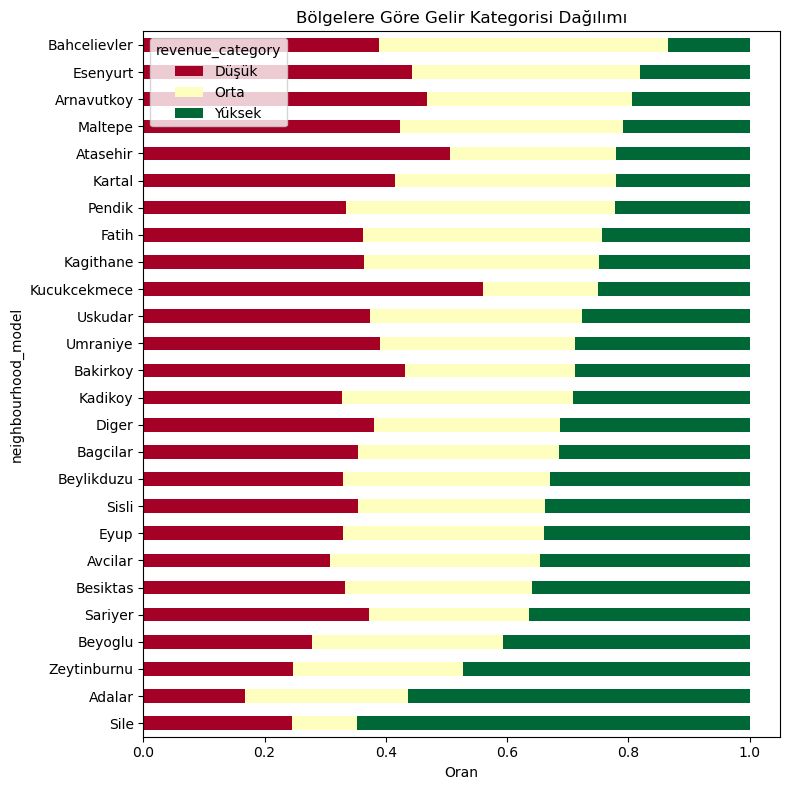

In [126]:
neighbourhood_revenue.plot(kind="barh", stacked=True, figsize=(8,8), colormap="RdYlGn")
plt.title("Bölgelere Göre Gelir Kategorisi Dağılımı")
plt.xlabel("Oran")
plt.tight_layout()
plt.show()

In [127]:
# Analiz/tahmin sonuçlarınızı içeren DataFrame'inizi CSV'ye aktarın
df_temizlenmis.to_csv("airbnb_python_outputs.csv", index=False, encoding="utf-8-sig")



In [128]:
importance_purchase = pd.DataFrame({
    'feature': X_train_p.columns,
    'importance': rf_clf_purchase.feature_importances_,
    'model_type': 'purchase_only'})

In [129]:
# 1) Tam feature set ile eğitilen model (rf_clf, X_train_c) — Cell 123'teki importances
importance_full = pd.DataFrame({
    'feature': X_train_c.columns,
    'importance': rf_clf.feature_importances_,
    'model_type': 'full_features'
})
    

In [130]:

# İkisini birleştir ve sırala
importance_df = pd.concat([importance_full, importance_purchase], ignore_index=True)
importance_df = importance_df.sort_values(['model_type', 'importance'], ascending=[True, False])

#importance_df.to_csv('feature_importance.csv', index=False)
importance_df.head(20)

,feature,importance,model_type
6,host_years_active,0.218147,full_features
5,reviews_per_month,0.208625,full_features
4,review_scores_rating,0.153946,full_features
0,accommodates,0.071595,full_features
3,beds,0.064200,full_features
1,bedrooms,0.039728,full_features
2,bathrooms,0.026617,full_features
33,room_type_Private room,0.023127,full_features
38,property_type_grouped_Rental unit,0.019422,full_features
15,neighbourhood_model_Beyoglu,0.017087,full_features


In [131]:
#importance_df.to_csv('feature_importance.csv', index=False, decimal=',', sep=';')

In [132]:
neighbourhood_revenue_long = neighbourhood_revenue.reset_index().melt(
    id_vars="neighbourhood_model",
    var_name="revenue_category",
    value_name="oran")

#neighbourhood_revenue_long.to_csv('neighbourhood_revenue.csv',index=False,decimal=',',sep=';')

In [133]:
#import joblib


In [134]:
#joblib.dump(df_temizlenmis, 'model.pkl')
#joblib.dump(X.columns.tolist(), 'model_columns.pkl')

#meta = {
    #'neighbourhoods': sorted(df_temizlenmis['neighbourhood_model'].unique().tolist()),
    #'room_types': sorted(df_temizlenmis['room_type'].unique().tolist()),
    #'property_types': sorted(df_temizlenmis['property_type_grouped'].unique().tolist()),
#}
#joblib.dump(meta, 'model_meta.pkl')

#print("Kaydedildi: model.pkl, model_columns.pkl, model_meta.pkl")
#print("Bu 3 dosyayı Streamlit app.py ile AYNI klasöre koy.")

In [135]:
# =====================================================================
# PBI ICIN: rf_clf_purchase MODELINE GORE ILK 5 ILCE ONERISI
# =====================================================================

# "Yuksek" sinifinin modeldeki index'ini bul
yuksek_idx = list(rf_clf_purchase.classes_).index("Yüksek")

# X_purchase'daki her satir icin "Yuksek" olma olasiligini hesapla
proba_yuksek = rf_clf_purchase.predict_proba(X_purchase)[:, yuksek_idx]

# Ilceyi (neighbourhood_model) X_purchase'in index'i uzerinden geri esle
neighbourhood_of_row = df_temizlenmis.loc[X_purchase.index, "neighbourhood_model"]

proba_df = pd.DataFrame({
    "neighbourhood_model": neighbourhood_of_row,
    "proba_yuksek_gelir": proba_yuksek
})

# Ilce bazinda ortalama "Yuksek gelir" olasiligi
ilce_oneri = (
    proba_df.groupby("neighbourhood_model")["proba_yuksek_gelir"]
    .mean()
    .reset_index()
    .sort_values("proba_yuksek_gelir", ascending=False)
)

ilce_oneri["rank"] = range(1, len(ilce_oneri) + 1)

top5_ilce = ilce_oneri.head(5)

print(top5_ilce)

# PBI icin CSV
#top5_ilce.to_csv(
    #"pbi_ilk5_ilce_onerisi.csv",
    #index=False,
    #decimal=",",
    #sep=";")
#print("Kaydedildi: pbi_ilk5_ilce_onerisi.csv")

   neighbourhood_model  proba_yuksek_gelir  rank
21                Sile            0.628581     1
25         Zeytinburnu            0.503741     2
0               Adalar            0.500451     3
9              Beyoglu            0.401578     4
3              Avcilar            0.370672     5


In [136]:
# =====================================================================
# REVENUE_CATEGORY SINIRLARINI (ESIK DEGERLERINI) CIKAR - PBI ICIN
# =====================================================================

df_temizlenmis["revenue_category"], bin_edges = pd.qcut(
    df_temizlenmis["est_annual_revenue"],
    q=3,
    labels=["Düşük", "Orta", "Yüksek"],
    retbins=True   # sinir degerlerini de dondur
)

# bin_edges 4 deger icerir: [min, esik1, esik2, max]
kategori_esikleri = pd.DataFrame({
    "revenue_category": ["Düşük", "Orta", "Yüksek"],
    "min_tl": bin_edges[:-1],
    "max_tl": bin_edges[1:]
})

kategori_esikleri["aciklama"] = (
    kategori_esikleri["revenue_category"] + ": " +
    kategori_esikleri["min_tl"].round(0).astype(int).astype(str) + " TL - " +
    kategori_esikleri["max_tl"].round(0).astype(int).astype(str) + " TL"
)

print(kategori_esikleri)

# PBI icin CSV
#kategori_esikleri.to_csv("pbi_revenue_kategori_esikleri.csv",index=False,decimal=",", sep=";")
print("Kaydedildi: pbi_revenue_kategori_esikleri.csv")

  revenue_category         min_tl        max_tl  \
0            Düşük       0.000000  6.081467e+04   
1             Orta   60814.666667  3.333673e+05   
2           Yüksek  333367.333333  3.038813e+06   

                         aciklama  
0          Düşük: 0 TL - 60815 TL  
1      Orta: 60815 TL - 333367 TL  
2  Yüksek: 333367 TL - 3038813 TL  
Kaydedildi: pbi_revenue_kategori_esikleri.csv


In [137]:
# =====================================================================
# PBI ICIN: MULK TIPINE GORE KIRILIMLI ILCE ONERISI
# =====================================================================

yuksek_idx = list(rf_clf_purchase.classes_).index("Yüksek")
proba_yuksek = rf_clf_purchase.predict_proba(X_purchase)[:, yuksek_idx]

detay_df = pd.DataFrame({
    "neighbourhood_model": df_temizlenmis.loc[X_purchase.index, "neighbourhood_model"],
    "property_type_grouped": df_temizlenmis.loc[X_purchase.index, "property_type_grouped"],
    "proba_yuksek_gelir": proba_yuksek
})

# Ilce + mulk tipi kirilimda ortalama olasilik ve ornek sayisi
oneri_detay = (
    detay_df.groupby(["property_type_grouped", "neighbourhood_model"])
    .agg(proba_yuksek_gelir=("proba_yuksek_gelir", "mean"),
         ilan_sayisi=("proba_yuksek_gelir", "size"))
    .reset_index()
)

# Az ornekli kombinasyonlari isaretle (guven duzeyi dusuk)
MIN_ILAN = 20
oneri_detay["yeterli_veri"] = oneri_detay["ilan_sayisi"] >= MIN_ILAN

# Her mulk tipi icin ilceleri sirala, rank ver
oneri_detay["rank"] = (
    oneri_detay.groupby("property_type_grouped")["proba_yuksek_gelir"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Her mulk tipi icin ilk 5 ilceyi tut
top5_detay = oneri_detay[oneri_detay["rank"] <= 5].sort_values(
    ["property_type_grouped", "rank"]
)

print(top5_detay)

#top5_detay.to_csv( "pbi_ilce_onerisi_mulk_tipine_gore.csv", index=False, decimal=",",sep=";")
print("Kaydedildi: pbi_ilce_onerisi_mulk_tipine_gore.csv")

    property_type_grouped neighbourhood_model  proba_yuksek_gelir  \
21              Apartment                Sile            0.777394   
9               Apartment             Beyoglu            0.512893   
25              Apartment         Zeytinburnu            0.485519   
20              Apartment             Sariyer            0.416656   
8               Apartment          Beylikduzu            0.366698   
47                   Home                Sile            0.903985   
29                   Home             Avcilar            0.785944   
34                   Home          Beylikduzu            0.589191   
49                   Home            Umraniye            0.556099   
26                   Home              Adalar            0.543289   
52                  Hotel              Adalar            0.653629   
62                  Hotel               Diger            0.621630   
71                  Hotel                Sile            0.617288   
59                  Hotel         

In [138]:
# =====================================================================
# PBI ICIN: MULK TIPINE GORE KIRILIMLI ILCE ONERISI (GUVENILIRLIK FILTRELI)
# =====================================================================

yuksek_idx = list(rf_clf_purchase.classes_).index("Yüksek")
proba_yuksek = rf_clf_purchase.predict_proba(X_purchase)[:, yuksek_idx]

detay_df = pd.DataFrame({
    "neighbourhood_model": df_temizlenmis.loc[X_purchase.index, "neighbourhood_model"],
    "property_type_grouped": df_temizlenmis.loc[X_purchase.index, "property_type_grouped"],
    "proba_yuksek_gelir": proba_yuksek
})

# Ilce + mulk tipi kirilimda ortalama olasilik ve ornek sayisi
oneri_detay = (
    detay_df.groupby(["property_type_grouped", "neighbourhood_model"])
    .agg(proba_yuksek_gelir=("proba_yuksek_gelir", "mean"),
         ilan_sayisi=("proba_yuksek_gelir", "size"))
    .reset_index()
)

# Guvenilirlik esigini yukselttik: 20 -> 30
MIN_ILAN = 30

# ONEMLI: filtreyi rank'ten ONCE uyguluyoruz, boylece az veriye
# dayanan satirlar rank 1 falan alip listeye hic girmiyor
oneri_guvenilir = oneri_detay[oneri_detay["ilan_sayisi"] >= MIN_ILAN].copy()

oneri_guvenilir["rank"] = (
    oneri_guvenilir.groupby("property_type_grouped")["proba_yuksek_gelir"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Her mulk tipi icin ilk 5 (veya daha azi varsa hepsini) tut
top5_guvenilir = oneri_guvenilir[oneri_guvenilir["rank"] <= 5].sort_values(
    ["property_type_grouped", "rank"]
)

print(top5_guvenilir)

#top5_guvenilir.to_csv("pbi_ilce_onerisi_mulk_tipine_gore_v2.csv", index=False, decimal=",",sep=";")
print("Kaydedildi: pbi_ilce_onerisi_mulk_tipine_gore_v2.csv")

# Kac mulk tipi/ilce kombinasyonu esik altinda kaldigini da gorelim
print(f"\nToplam kombinasyon: {len(oneri_detay)}")
print(f"Esik altinda elenen: {(oneri_detay['ilan_sayisi'] < MIN_ILAN).sum()}")
print(f"Esik ustunde kalan: {len(oneri_guvenilir)}")

    property_type_grouped neighbourhood_model  proba_yuksek_gelir  \
9               Apartment             Beyoglu            0.512893   
14              Apartment             Kadikoy            0.362414   
18              Apartment             Maltepe            0.318557   
22              Apartment               Sisli            0.302423   
2               Apartment            Atasehir            0.273794   
48                   Home               Sisli            0.447438   
36                   Home               Diger            0.408782   
46                   Home             Sariyer            0.400894   
35                   Home             Beyoglu            0.388692   
50                   Home             Uskudar            0.365750   
52                  Hotel              Adalar            0.653629   
59                  Hotel            Besiktas            0.548549   
72                  Hotel               Sisli            0.421417   
61                  Hotel         

In [139]:
detay_df3 = pd.DataFrame({
    "neighbourhood_model": df_temizlenmis.loc[X_purchase.index, "neighbourhood_model"],
    "property_type_grouped": df_temizlenmis.loc[X_purchase.index, "property_type_grouped"],
    "room_type": df_temizlenmis.loc[X_purchase.index, "room_type"],
    "proba_yuksek_gelir": proba_yuksek
})

test_groupby = (
    detay_df3.groupby(["property_type_grouped", "room_type", "neighbourhood_model"])
    .size()
    .reset_index(name="ilan_sayisi")
)

print(f"Toplam kombinasyon: {len(test_groupby)}")
print(f"30 ilan esigini gecen: {(test_groupby['ilan_sayisi'] >= 30).sum()}")
print(f"Gecen oran: {(test_groupby['ilan_sayisi'] >= 30).mean():.1%}")

Toplam kombinasyon: 263
30 ilan esigini gecen: 62
Gecen oran: 23.6%


In [140]:
test_groupby_room = (
    detay_df3.groupby(["room_type", "neighbourhood_model"])
    .size()
    .reset_index(name="ilan_sayisi")
)

print(f"Toplam kombinasyon: {len(test_groupby_room)}")
print(f"30 ilan esigini gecen: {(test_groupby_room['ilan_sayisi'] >= 30).sum()}")
print(f"Gecen oran: {(test_groupby_room['ilan_sayisi'] >= 30).mean():.1%}")

Toplam kombinasyon: 79
30 ilan esigini gecen: 45
Gecen oran: 57.0%


In [141]:
# =====================================================================
# PBI ICIN: ODA TIPINE GORE KIRILIMLI ILCE ONERISI
# =====================================================================

oneri_room = (
    detay_df3.groupby(["room_type", "neighbourhood_model"])
    .agg(proba_yuksek_gelir=("proba_yuksek_gelir", "mean"),
         ilan_sayisi=("proba_yuksek_gelir", "size"))
    .reset_index()
)

MIN_ILAN = 30
oneri_room_guvenilir = oneri_room[oneri_room["ilan_sayisi"] >= MIN_ILAN].copy()

oneri_room_guvenilir["rank"] = (
    oneri_room_guvenilir.groupby("room_type")["proba_yuksek_gelir"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top5_room = oneri_room_guvenilir[oneri_room_guvenilir["rank"] <= 5].sort_values(
    ["room_type", "rank"]
)

print(top5_room)

top5_room.to_csv(
    "pbi_ilce_onerisi_oda_tipine_gore.csv",
    index=False,
    decimal=",",
    sep=";"
)
print("Kaydedildi: pbi_ilce_onerisi_oda_tipine_gore.csv")

          room_type neighbourhood_model  proba_yuksek_gelir  ilan_sayisi  rank
21  Entire home/apt                Sile            0.670950          130     1
25  Entire home/apt         Zeytinburnu            0.552244           84     2
0   Entire home/apt              Adalar            0.474014           85     3
20  Entire home/apt             Sariyer            0.459846           90     4
17  Entire home/apt        Kucukcekmece            0.443729           43     5
29       Hotel room             Beyoglu            0.377375           30     1
31       Hotel room               Fatih            0.290005           78     2
36     Private room              Adalar            0.559532           61     1
46     Private room               Diger            0.234606           72     2
45     Private room             Beyoglu            0.203082          568     3
42     Private room            Bakirkoy            0.140264           40     4
49     Private room               Fatih            0

In [143]:
# =====================================================================
# PBI ICIN: PURCHASE-TIME MODELIN FEATURE IMPORTANCE'I
# =====================================================================

importances_purchase = pd.DataFrame({
    "feature": X_purchase.columns,
    "importance": rf_clf_purchase.feature_importances_
}).sort_values("importance", ascending=False)

importances_purchase["importance_pct"] = (
    importances_purchase["importance"] / importances_purchase["importance"].sum() * 100
).round(0).astype(int)

print(importances_purchase)

importances_purchase.to_csv(
    "pbi_feature_importance_purchase.csv",
    index=False,
    decimal=",",
    sep=";"
)
print("Kaydedildi: pbi_feature_importance_purchase.csv")

                              feature  importance  importance_pct
3                                beds    0.185129              19
0                        accommodates    0.183867              18
1                            bedrooms    0.089017               9
2                           bathrooms    0.074548               7
4                   host_is_superhost    0.047912               5
31             room_type_Private room    0.044997               4
36  property_type_grouped_Rental unit    0.038138               4
13        neighbourhood_model_Beyoglu    0.025166               3
17          neighbourhood_model_Fatih    0.021969               2
26          neighbourhood_model_Sisli    0.021628               2
33         property_type_grouped_Home    0.021384               2
18        neighbourhood_model_Kadikoy    0.019550               2
35   property_type_grouped_Other_type    0.018735               2
11       neighbourhood_model_Besiktas    0.018189               2
34        